# Classification with BORF, step by step

This notebook walks through the whole process of classifying time series with
Bag-Of-Receptive-Fields (BORF) and explaining the predictions:

1. how BORF turns a series into SAX words, and words into features;
2. a classifier on BORF features for regularly sampled series (CBF);
3. explanations: saliency maps, receptive fields and the patterns behind the predictions;
4. the same for irregularly sampled series (Alembics Bowls Flasks).

To run it, install the package with the extra dependencies of the notebooks
(aeon and pyrregular for the datasets, SHAP, matplotlib and seaborn):

```bash
pip install "fast-borf[notebooks] @ git+https://github.com/fspinna/borf"
```

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns
from aeon.datasets import load_classification
from matplotlib import patheffects
from matplotlib.collections import LineCollection
from matplotlib.colors import CenteredNorm
from scipy.spatial.distance import cdist
from shap import LinearExplainer
from sklearn.linear_model import RidgeClassifierCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer

from fast_borf import BORF
from fast_borf.core import breakpoints, decode_words, sax_words, segment_means, window_positions
from fast_borf.xai import BagOfReceptiveFields

sns.set_context("paper", font_scale=1.5)
sns.set_style("white")

IMPORTANCE_CMAP = plt.get_cmap("coolwarm")  # blue: against the class, red: for it
# Categorical colors, in a fixed order: classes, and the segments of a window.
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
rng = np.random.default_rng(0)

## 1. Data: Cylinder Bell Funnel

CBF has three classes of noisy shapes of length 128: a *cylinder* (a plateau), a
*bell* (a ramp up followed by a drop) and a *funnel* (a jump followed by a ramp
down). BORF expects an array of shape `(n_series, n_signals, n_timestamps)`;
here there is one signal per series.

In [2]:
X_train, y_train = load_classification("CBF", split="train")
X_test, y_test = load_classification("CBF", split="test")
y_train, y_test = y_train.astype(int) - 1, y_test.astype(int) - 1
labels = ["Cylinder", "Bell", "Funnel"]
print(X_train.shape, X_test.shape)

(30, 1, 128) (900, 1, 128)


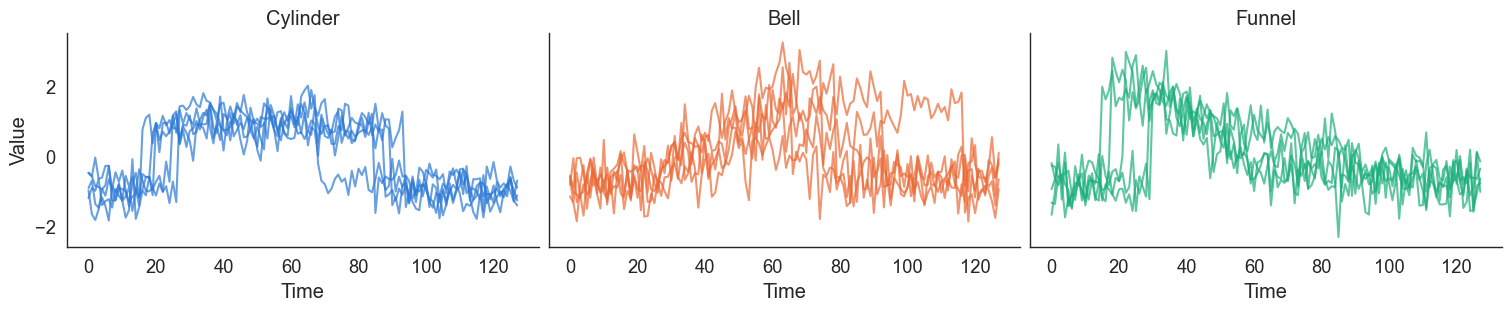

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharey=True, layout="constrained")
for c, ax in enumerate(axs):
    for x in X_train[y_train == c][:5, 0]:
        ax.plot(x, c=COLORS[c], lw=1.5, alpha=0.7)
    ax.set_title(labels[c])
    ax.set_xlabel("Time")
axs[0].set_ylabel("Value")
sns.despine()

## 2. From a series to SAX words

BORF slides windows over each signal. A **configuration** fixes the window size,
the number of segments per window (the *word length*), the alphabet size, the
dilation (the window takes every *d*-th point) and the stride. For every window:

1. the points are split into `word_length` segments and each segment is
   averaged (Piecewise Aggregate Approximation, PAA);
2. the segment means are z-normalized with the window's own mean and standard
   deviation, so a word describes the *shape* of the window, not its level;
3. each normalized mean becomes a symbol, depending on which interval of the
   Gaussian breakpoints it falls in (SAX). The symbols form the word.

`fast_borf.core` exposes these steps, so we can follow one window by hand.

In [4]:
def delta_weights(timestamps):
    # Each observation is weighted by the time since the previous one (the
    # first gets the next gap). With even spacing all weights are equal.
    weights = np.diff(timestamps, prepend=np.nan)
    weights[0] = weights[1]
    return weights


def show_window(axs, signal, timestamps, config, k, title=None):
    """Draw window k of a signal: its segments on the series (left), and its
    normalized segment means, breakpoints and symbols (right)."""
    window_size, word_length = config["window_size"], config["word_length"]
    stride, dilation, alphabet_size = config["stride"], config["dilation"], config["alphabet_size"]
    means = segment_means(signal, timestamps, window_size, word_length, stride, dilation,
                          config.get("min_window_to_signal_std_ratio", 0.0))
    positions = window_positions(len(means), window_size, word_length, stride, dilation)[k]
    bins = breakpoints(alphabet_size)
    symbols = np.digitize(means[k], bins)

    ax = axs[0]
    ax.plot(timestamps, signal, c="lightgray", lw=2, zorder=0)
    for j, segment in enumerate(positions):
        ax.plot(timestamps[segment], signal[segment], "o", ms=6, c=COLORS[j], mec="white", mew=1)
    ax.set_title(title or "Window on the series")

    # Weighted mean and std of the window, as used to normalize the segment means.
    points = positions.ravel()
    w = delta_weights(timestamps)[points]
    mu = np.sum(w * signal[points]) / np.sum(w)
    sigma = np.sqrt(np.sum(w * (signal[points] - mu) ** 2) / np.sum(w))
    ax = axs[1]
    for b in bins:
        ax.axhline(b, c="gray", ls="--", lw=1, zorder=0)
    for j, segment in enumerate(positions):
        t = timestamps[segment]
        ax.plot(t, (signal[segment] - mu) / sigma, "o", ms=6, c=COLORS[j], alpha=0.5, mec="white", mew=1)
        ax.hlines(means[k, j], t[0], t[-1], colors=COLORS[j], lw=4)
        ax.annotate(str(symbols[j]), (t.mean(), means[k, j]), textcoords="offset points",
                    xytext=(0, 8), ha="center", fontweight="bold", color="black")
    ax.set_title(f"Word {symbols}")
    ax.set_ylabel("z-score")
    return symbols

Below, the same window position with two configurations: 4 segments of 8
consecutive points, and the same with dilation 2, which spreads the window over
twice the time. On the right, the dashed lines are the breakpoints of an
alphabet of 3 symbols: below the lower one is symbol 0, between them 1, above 2.

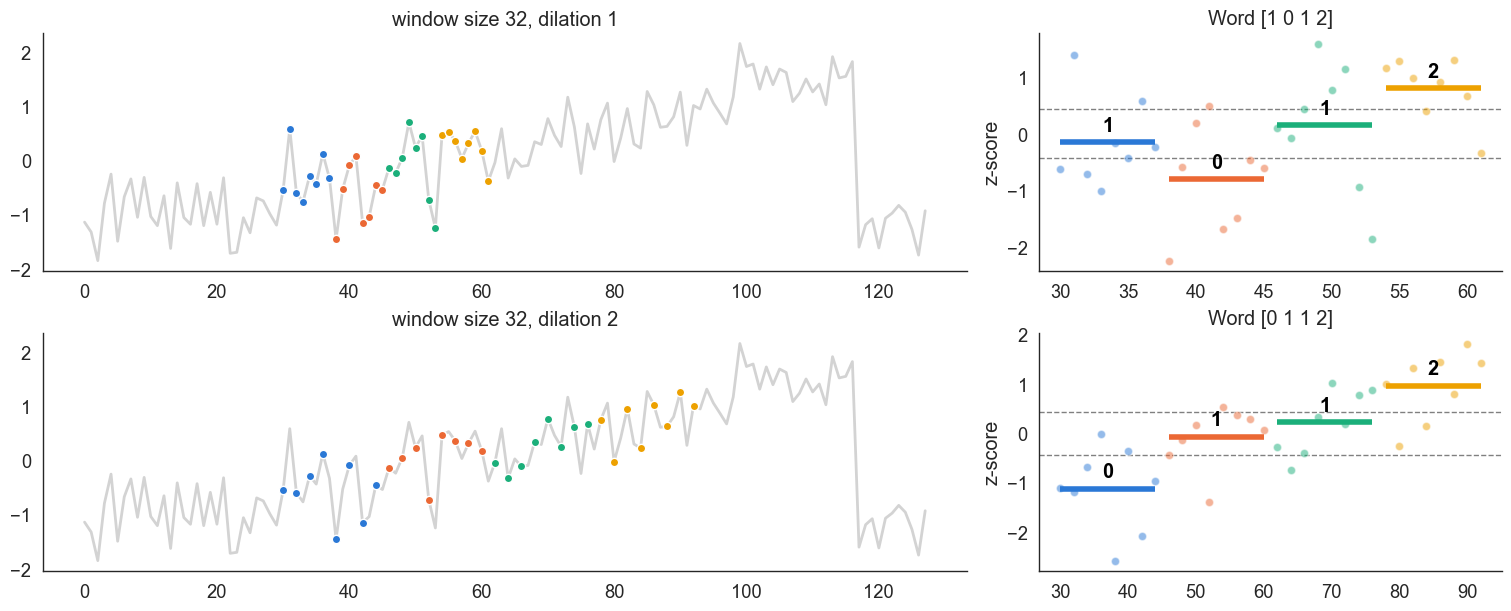

In [5]:
signal = X_train[np.flatnonzero(y_train == 1)[0], 0]  # a bell
timestamps = np.arange(signal.size, dtype=float)
examples = [
    dict(window_size=32, word_length=4, alphabet_size=3, stride=1, dilation=1),
    dict(window_size=32, word_length=4, alphabet_size=3, stride=1, dilation=2),
]
fig, axs = plt.subplots(2, 2, figsize=(15, 6), width_ratios=[2, 1], layout="constrained")
for row, config in zip(axs, examples):
    show_window(row, signal, timestamps, config, k=30,
                title=f"window size {config['window_size']}, dilation {config['dilation']}")
sns.despine()

Sliding the window gives one word per position, and the **bag of words** of the
signal counts how often each word occurs. For this configuration (word length
4, alphabet 3) there are $3^4 = 81$ possible words; most series use only some
of them.

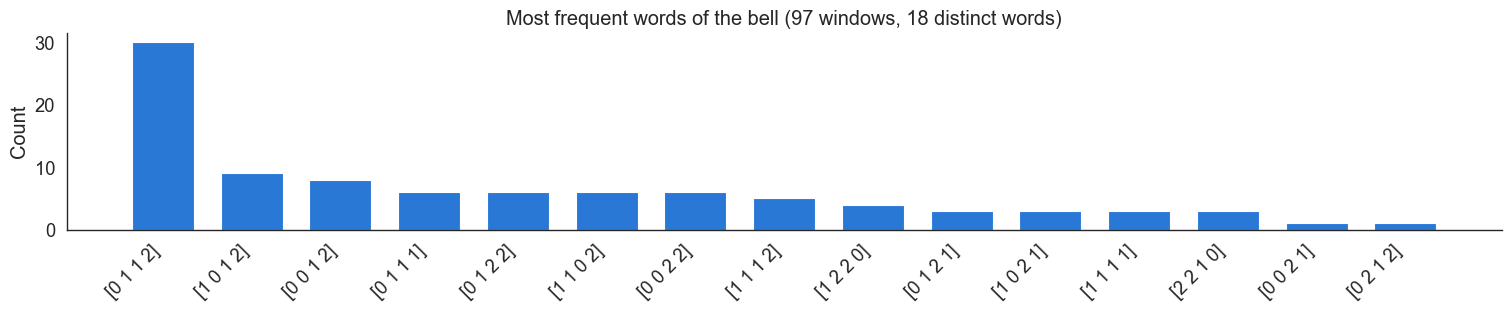

In [6]:
config = examples[0]
words = sax_words(signal, timestamps, config["window_size"], config["word_length"],
                  config["alphabet_size"], breakpoints(config["alphabet_size"]),
                  config["stride"], config["dilation"])
values, counts = np.unique(words, return_counts=True)
order = np.argsort(-counts)[:15]
names = [str(w) for w in decode_words(values[order], config["alphabet_size"], config["word_length"])]

fig, ax = plt.subplots(figsize=(15, 3), layout="constrained")
ax.bar(range(len(order)), counts[order], color=COLORS[0], width=0.7)
ax.set_xticks(range(len(order)), names, rotation=45, ha="right")
ax.set_ylabel("Count")
ax.set_title(f"Most frequent words of the bell ({len(words)} windows, {len(values)} distinct words)")
sns.despine()

## 3. BORF features and a classifier

BORF repeats this for many configurations, chosen from the series length:
window sizes and dilations are powers of two, word lengths 2, 4 and 8. Each
(configuration, signal, word) seen during training becomes a column, holding
the word's count, so the output is a wide and very sparse matrix.

The classifier is the usual one: `arcsinh` to damp large counts, then a ridge
classifier. `min_window_to_signal_std_ratio=0.15` treats nearly flat windows as
flat, so noise in flat regions does not create words.

In [7]:
pipe = make_pipeline(
    BORF(min_window_to_signal_std_ratio=0.15, n_jobs=-1),
    FunctionTransformer(np.arcsinh),
    RidgeClassifierCV(),
)
pipe.fit(X_train, y_train)
borf = pipe[0]
print(f"test accuracy: {pipe.score(X_test, y_test):.3f}")
print(f"{len(borf.configs_)} configurations, {len(borf.feature_index_)} features")

test accuracy: 1.000
42 configurations, 12925 features


Every column can be traced back to what it counts: `configs_` lists the
configurations, `config_slices_[i]` gives the columns of configuration `i`,
and `feature_index_` gives, for each column, its configuration, signal and word.

In [8]:
X_counts = borf.transform(X_test)
print(f"density of the feature matrix: {X_counts.nnz / np.prod(X_counts.shape):.1%}")
j = 1000
config_idx, signal_idx, word = borf.feature_index_[j]
config = borf.configs_[config_idx]
print(f"column {j}: configuration {config}")
print(f"          signal {signal_idx}, word {decode_words(np.array([word]), config['alphabet_size'], config['word_length'])[0]}")

density of the feature matrix: 6.8%
column 1000: configuration {'window_size': 8, 'stride': 1, 'dilation': 1, 'word_length': 8, 'alphabet_size': 3}
          signal 0, word [0 2 2 1 2 1 1 2]


## 4. Explanations

Explaining a prediction takes two steps:

1. **Feature importances**: how much each column pushed each series towards
   each class. Any per-series importances work. For a linear model, SHAP's
   `LinearExplainer` gives coefficient times the feature's deviation from the
   mean of the background data. By default SHAP uses a random sample of at
   most 100 background series; the training set here has 30, so the mean is
   exact, which we can check directly. SHAP itself is therefore optional.
2. **Mapping back**: `BagOfReceptiveFields` finds where each word occurs, down
   to the points of each segment (its *receptive field*), and spreads the
   importances onto the series.

In [9]:
model = pipe[-1]
Z_train, Z_test = pipe[:-1].transform(X_train), pipe[:-1].transform(X_test)
explainer = LinearExplainer(model, Z_train)
F = np.asarray(explainer.shap_values(Z_test)).transpose(2, 0, 1)  # (n_classes, n_series, n_features)

# The same without SHAP: coefficient times deviation from the training mean.
mean = np.asarray(Z_train.mean(axis=0)).ravel()
F_manual = np.stack([(Z_test.toarray() - mean) * coef for coef in model.coef_])
print("SHAP values equal coef * (x - mean):", np.allclose(F, F_manual))

SHAP values equal coef * (x - mean): True


`build` computes the words of the explained series, `add_feature_importance`
keeps the importances towards each series' predicted class, and the two
mapping steps compute:

- `S_`, the **saliency** of every point: the importance of the words occurring
  in the series, spread over the points their windows cover
  (`count_overlapping=False` counts each word once per point). By default each
  series' map is rescaled with one factor; `normalize="feature"` instead gives
  every word exactly its importance, spread over its own occurrences;
- `F_norm_`, the importance of the words **absent** from each series, which
  can matter just as much ("no plateau here" is evidence against Cylinder).

In [10]:
y_pred = pipe.predict(X_test)
mapper = BagOfReceptiveFields(borf)
mapper.build(X_test, y_test, y_pred, task="classification")
mapper.add_feature_importance(F)
mapper.map_contained_feature_importance_to_saliency(count_overlapping=False)
mapper.map_notcontained_feature_importance()
print(mapper.S_.shape, mapper.F_norm_.shape)

(900, 1, 128) (900, 12925)


### Explaining one series

On the left, the series colored by saliency: red points push towards the
predicted class, blue points against it. On the right, the most important
pattern the series does *not* contain, drawn where it occurs in another series
(its most typical occurrence), with the series in gray for reference.

In [11]:
def colored_line(ax, t, x, values, norm, lw=3):
    points = np.array([t, x]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    collection = LineCollection(segments, cmap=IMPORTANCE_CMAP, norm=norm, lw=lw)
    collection.set_array((values[:-1] + values[1:]) / 2)
    ax.add_collection(collection)
    ax.autoscale()


def zscore(x):
    return (x - np.nanmean(x)) / np.nanstd(x)


def occurrences(mapper, feature):
    """All occurrences of a feature's word: series index, point indices, timestamps, values."""
    field = mapper.receptive_fields_[feature]
    series = np.concatenate([np.full(len(a), i) for i, a in enumerate(field.alignments_indices)])
    if not len(series):
        return field, series, None, None, None
    indices = np.concatenate(field.alignments_indices).reshape(len(series), -1)
    times = np.concatenate(field.alignments).reshape(len(series), -1)
    values = np.concatenate(field.mappings).reshape(len(series), -1)
    return field, series, indices, times, values


def most_important_absent(mapper, i, signal_idx):
    """Absent features of a signal, most important first, that occur in some series.

    Ranked by their importance F_, not by F_norm_: with normalize="feature",
    F_norm_ is per point and would favour the shortest windows.
    """
    candidates = np.flatnonzero(~np.isnan(mapper.F_norm_[i]) & (mapper.mapping[:, 1] == signal_idx))
    for feature in candidates[np.argsort(-np.abs(mapper.F_[i, candidates]), kind="stable")]:
        if occurrences(mapper, feature)[1].size:
            yield feature


def plot_explanation(mapper, i, labels):
    n_signals = mapper.X_.shape[1]
    f_norm = mapper.F_norm_[i]
    norm = CenteredNorm()
    norm(np.concatenate([mapper.S_[i].ravel(), f_norm[~np.isnan(f_norm)]]))
    fig, axs = plt.subplots(n_signals, 2, figsize=(15, 2.8 * n_signals), sharey=True,
                            squeeze=False, layout="constrained")
    for s in range(n_signals):
        x, t = mapper.X_[i, s], mapper.timestamps_[i, 0]
        keep = ~np.isnan(x)
        colored_line(axs[s, 0], t[keep], zscore(x[keep]), mapper.S_[i, s][keep], norm)
        axs[s, 0].yaxis.set_major_locator(ticker.MultipleLocator(1))
        axs[s, 0].set_title(f"{labels[mapper.y_true_[i]]} series, predicted {labels[mapper.y_pred_[i]]}")

        feature = next(most_important_absent(mapper, i, s))
        field, series, _, times, values = occurrences(mapper, feature)
        # Values of each occurrence, z-scored like its own series.
        values = np.stack([(v - np.nanmean(mapper.X_[k, s])) / np.nanstd(mapper.X_[k, s])
                           for v, k in zip(values, series)])
        medoid = np.argmin(cdist(values, values).sum(axis=0))
        axs[s, 1].plot(t[keep], zscore(x[keep]), c="lightgray", lw=3, alpha=0.5)
        outline = [patheffects.Stroke(linewidth=5.5, foreground="dimgray"), patheffects.Normal()]
        axs[s, 1].plot(times[medoid], values[medoid], c=IMPORTANCE_CMAP(norm(f_norm[feature])),
                       lw=3, marker="o", ms=5, label=str(field.word_array), path_effects=outline)
        axs[s, 1].legend(loc="lower right", frameon=False)
        axs[s, 1].set_title("Most important not contained pattern")
    colorbar = fig.colorbar(mpl.cm.ScalarMappable(cmap=IMPORTANCE_CMAP, norm=norm), ax=axs)
    colorbar.set_ticks([norm.vmin, 0, norm.vmax], labels=[r"$-$", "0", r"$+$"])
    colorbar.set_label("SHAP value")
    sns.despine()
    return fig

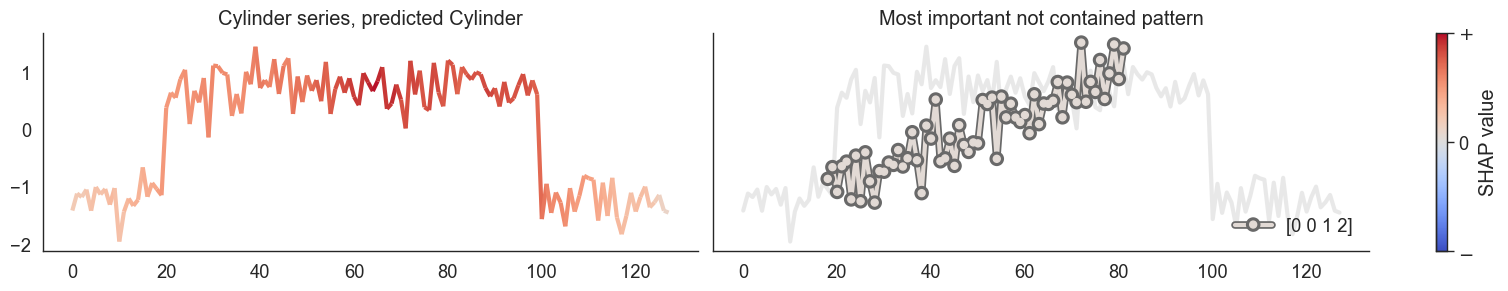

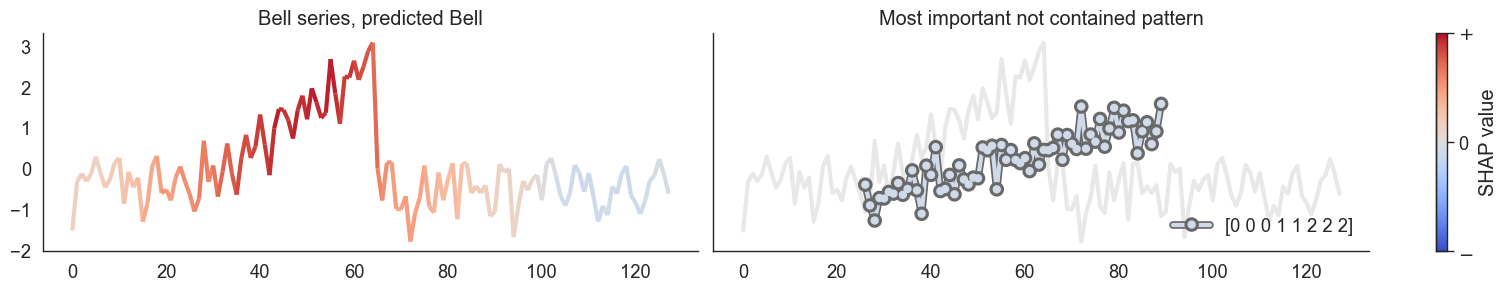

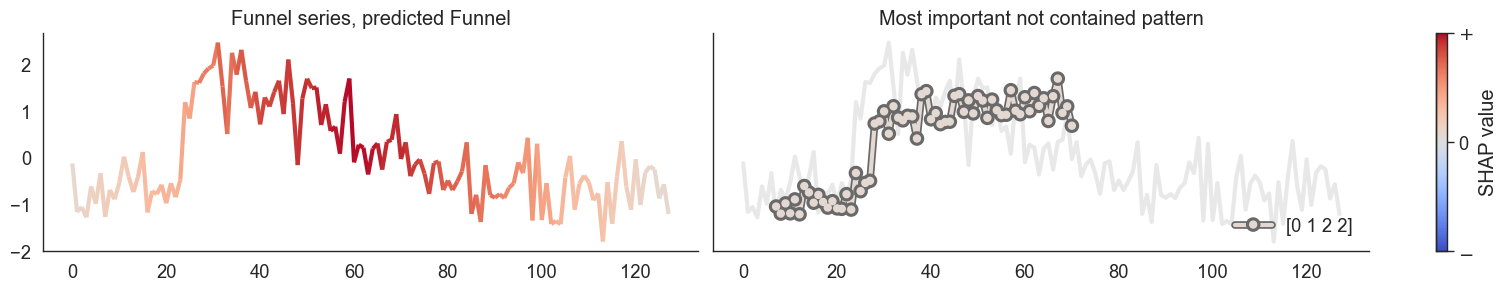

In [12]:
for c in range(3):
    plot_explanation(mapper, np.flatnonzero(y_pred == c)[0], labels)

### The most important patterns

`F_avg_rank_argsort_` ranks features by their average rank of absolute
importance across series. For the top patterns, on the left, their
occurrences in the test set (a random sample of up to 200), aligned at their
start and z-normalized: the receptive fields, with the median shape in dark
gray. The same word can matter in several configurations, which differ by
window size and dilation. On the right, how often
each series contains the pattern, grouped by predicted class and colored by
the pattern's importance in that series.

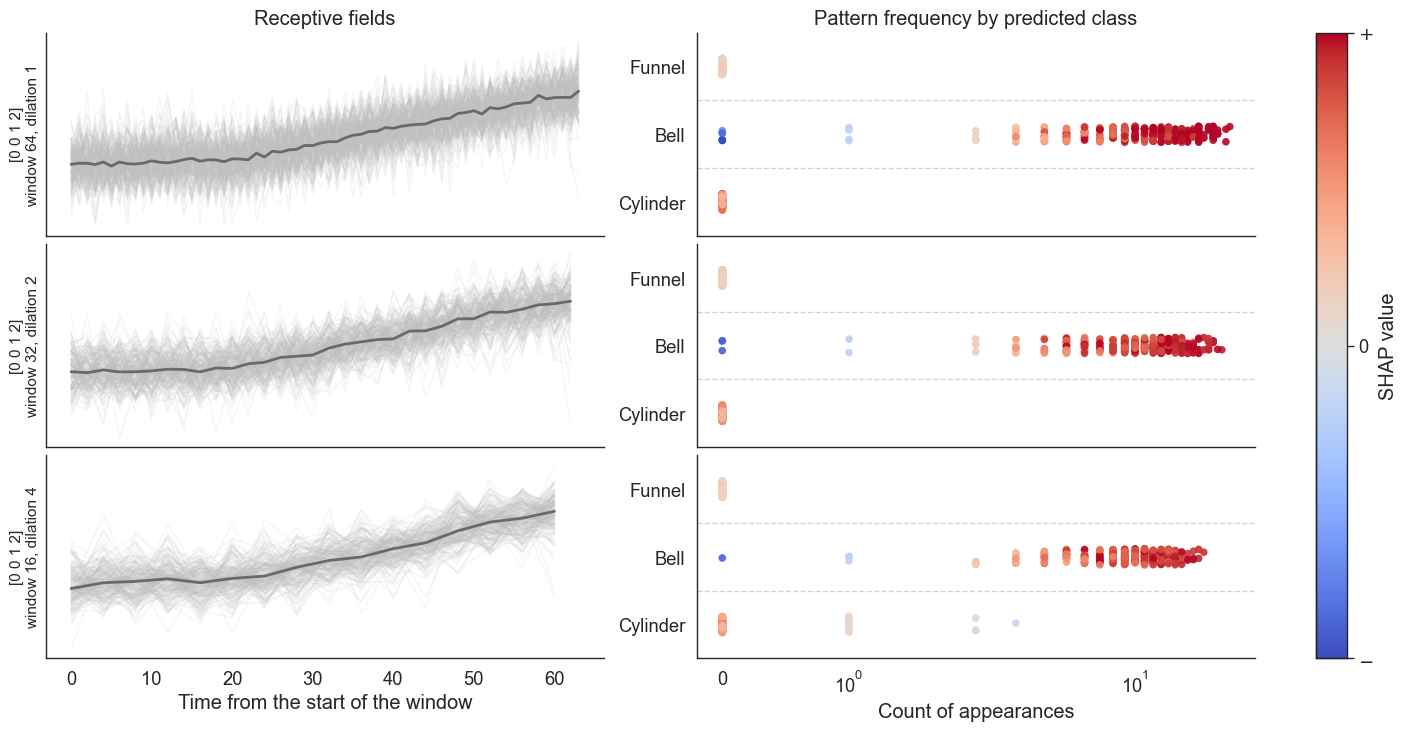

In [13]:
def jitter(values, amount=0.12):
    return values + rng.uniform(-amount, amount, len(values))


def plot_top_patterns(mapper, labels, n_patterns=3):
    fig, axs = plt.subplots(n_patterns, 2, figsize=(14, 2.4 * n_patterns), sharex="col",
                            squeeze=False, layout="constrained")
    # Each series' importances are scaled to its own range, as in the saliency plots.
    scale = np.abs(mapper.F_).max(axis=1, keepdims=True)
    for a, feature in enumerate(mapper.F_avg_rank_argsort_[:n_patterns]):
        field, series, _, times, values = occurrences(mapper, feature)
        sample = rng.choice(len(series), min(200, len(series)), replace=False)
        times, values = times[sample], values[sample]
        start = times - times[:, :1]
        shapes = (values - values.mean(axis=1, keepdims=True)) / (values.std(axis=1, keepdims=True) + 1e-6)
        axs[a, 0].plot(start.T, shapes.T, c="silver", alpha=0.15, lw=1, zorder=0)
        axs[a, 0].plot(np.median(start, axis=0), np.median(shapes, axis=0), c="dimgray", lw=2)
        axs[a, 0].set_ylabel(f"{field.word_array}\nwindow {field.window_size}, dilation {field.dilation}",
                             fontsize=11)
        axs[a, 0].set_yticks([])

        counts = mapper.X_transformed_[:, feature].toarray().ravel()
        colors = IMPORTANCE_CMAP((mapper.F_[:, feature] / scale[:, 0] + 1) / 2)
        axs[a, 1].scatter(counts, jitter(mapper.y_pred_), c=colors, s=30, alpha=0.9, lw=0)
        axs[a, 1].set_xscale("symlog")
        axs[a, 1].set_yticks(range(len(labels)), labels)
        axs[a, 1].set_ylim(-0.5, len(labels) - 0.5)
        for b in range(len(labels) - 1):
            axs[a, 1].axhline(b + 0.5, c="lightgray", ls="--", lw=1)
    axs[0, 0].set_title("Receptive fields")
    axs[0, 1].set_title("Pattern frequency by predicted class")
    axs[-1, 0].set_xlabel("Time from the start of the window")
    axs[-1, 1].set_xlabel("Count of appearances")
    norm = mpl.colors.Normalize(-1, 1)
    colorbar = fig.colorbar(mpl.cm.ScalarMappable(cmap=IMPORTANCE_CMAP, norm=norm), ax=axs)
    colorbar.set_ticks([-1, 0, 1], labels=[r"$-$", "0", r"$+$"])
    colorbar.set_label("SHAP value")
    sns.despine()
    return fig


plot_top_patterns(mapper, labels, n_patterns=3);

### One receptive field, down to the segments

A receptive field records, for every occurrence of a word, the exact points of
each segment. Here is the top pattern in one series that contains it: its
segments on the series, and how their normalized means produce the word.

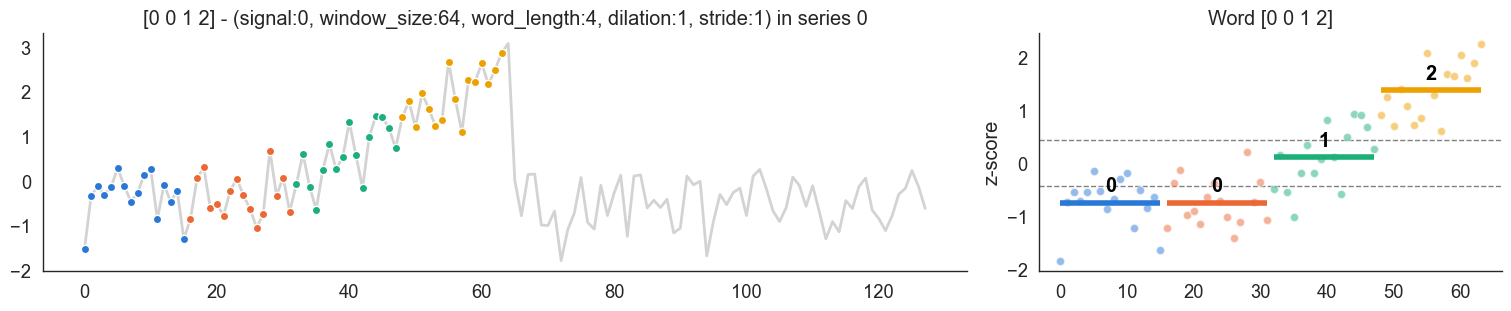

In [14]:
def plot_receptive_field(mapper, feature, i, occurrence=0):
    field = mapper.receptive_fields_[feature]
    config = mapper.configs[field.conf_idx]
    s = field.signal_idx
    x, t = mapper.X_[i, s], mapper.timestamps_[i, 0].astype(float)
    keep = np.flatnonzero(~np.isnan(x))
    # The window index among the windows of the observed points.
    start = np.searchsorted(keep, field.alignments_indices[i][occurrence][0, 0])
    k = start // config["stride"]
    fig, axs = plt.subplots(1, 2, figsize=(15, 3), width_ratios=[2, 1], layout="constrained")
    symbols = show_window(axs, x[keep], t[keep], config, k, title=f"{field} in series {i}")
    assert np.array_equal(symbols, field.word_array)
    sns.despine()
    return fig


top = mapper.F_avg_rank_argsort_[0]
i = next(i for i, a in enumerate(mapper.receptive_fields_[top].alignments_indices) if len(a))
plot_receptive_field(mapper, top, i);

## 5. Irregularly sampled series: Alembics Bowls Flasks

Alembics Bowls Flasks is an irregularly sampled counterpart of CBF: three
classes of shapes, but each series is observed at its own irregular times. The
timestamps go in an extra last channel, and `BORF(time_channel=True)` uses them:
each observation is weighted by the time since the previous one, so densely
sampled stretches do not dominate the averages.

In [15]:
from pyrregular import load_dataset

data = load_dataset("Abf")["data"]
y, split = data.irr.get_task_target_and_split()
X, _ = data.irr.to_dense(concatenate_time=True, normalize_time=True)  # last channel: time
names = dict(zip(data.class_default.values, data.class_labels.values))
abf_labels = [str(names[c]).capitalize() for c in range(len(names))]
Xa_train, ya_train = X[split == "train"], y[split == "train"]
Xa_test, ya_test = X[split == "test"], y[split == "test"]
print(Xa_train.shape, Xa_test.shape, abf_labels)

(30, 2, 128) (900, 2, 128) ['Bowl', 'Alembic', 'Flask']


time between observations: median 0.0038, 5th percentile 0.00026, 95th percentile 0.0254


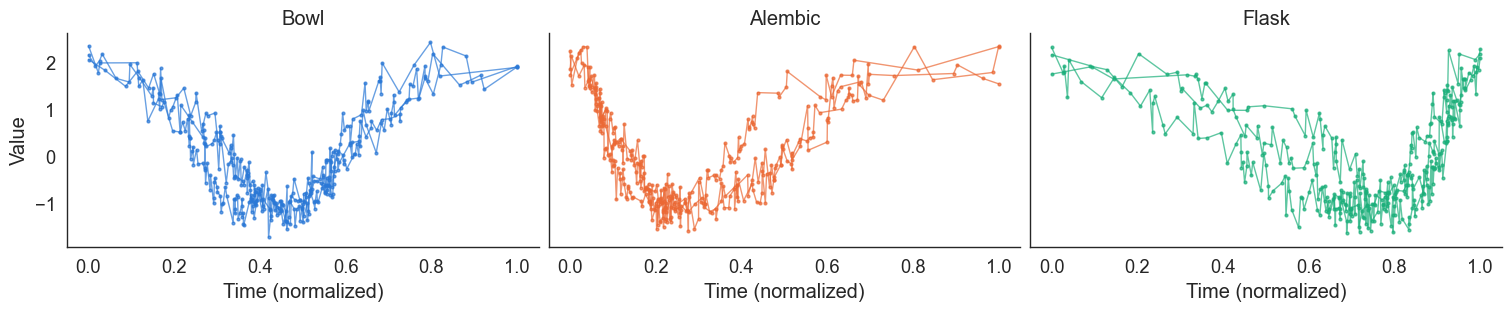

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharey=True, layout="constrained")
for c, ax in enumerate(axs):
    for series in Xa_train[ya_train == c][:3]:
        ax.plot(series[-1], series[0], "-o", ms=2, c=COLORS[c], lw=1, alpha=0.7)
    ax.set_title(abf_labels[c])
    ax.set_xlabel("Time (normalized)")
axs[0].set_ylabel("Value")
sns.despine()

gaps = np.diff(Xa_train[:, -1], axis=1).ravel()
print(f"time between observations: median {np.median(gaps):.4f}, "
      f"5th percentile {np.percentile(gaps, 5):.5f}, 95th percentile {np.percentile(gaps, 95):.4f}")

The pipeline is the same, with `time_channel=True`. For comparison, the same
model ignoring the timestamps, which treats the observations as evenly spaced.

In [17]:
pipe_irr = make_pipeline(
    BORF(min_window_to_signal_std_ratio=0.15, time_channel=True, n_jobs=-1),
    FunctionTransformer(np.arcsinh),
    RidgeClassifierCV(),
)
pipe_irr.fit(Xa_train, ya_train)
print(f"with timestamps:     test accuracy {pipe_irr.score(Xa_test, ya_test):.3f}")

pipe_no_time = make_pipeline(
    BORF(min_window_to_signal_std_ratio=0.15, n_jobs=-1), FunctionTransformer(np.arcsinh), RidgeClassifierCV()
)
pipe_no_time.fit(Xa_train[:, :-1], ya_train)
print(f"ignoring timestamps: test accuracy {pipe_no_time.score(Xa_test[:, :-1], ya_test):.3f}")

with timestamps:     test accuracy 0.900


ignoring timestamps: test accuracy 0.333


The explanations work the same way. Saliency and receptive fields are now drawn
against the real timestamps, and the windows follow the observations: a window
of 16 observations can span a short or a long stretch of time.

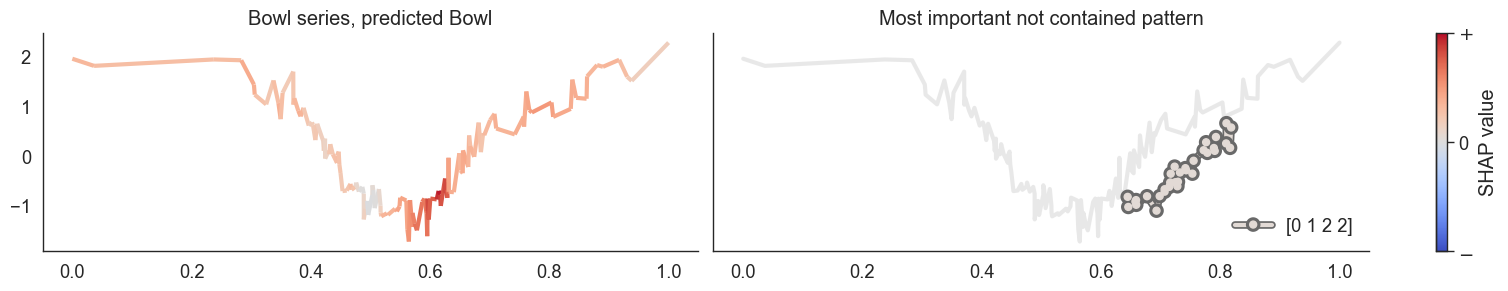

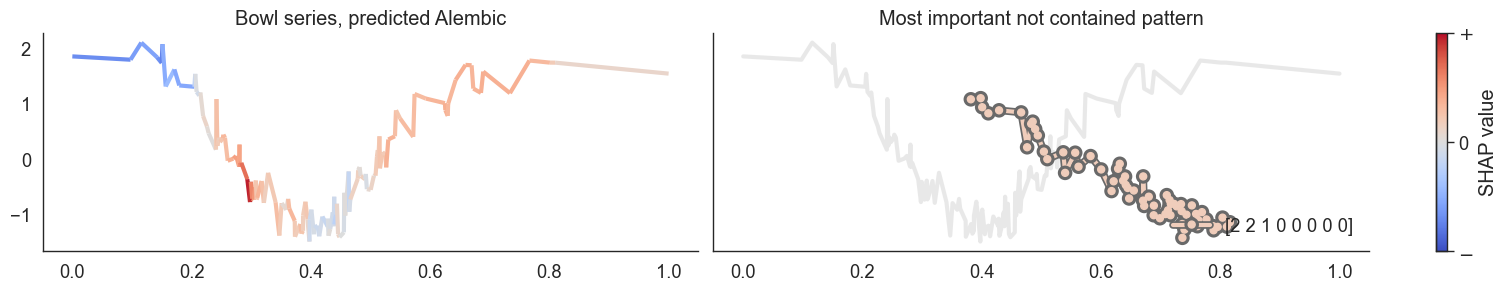

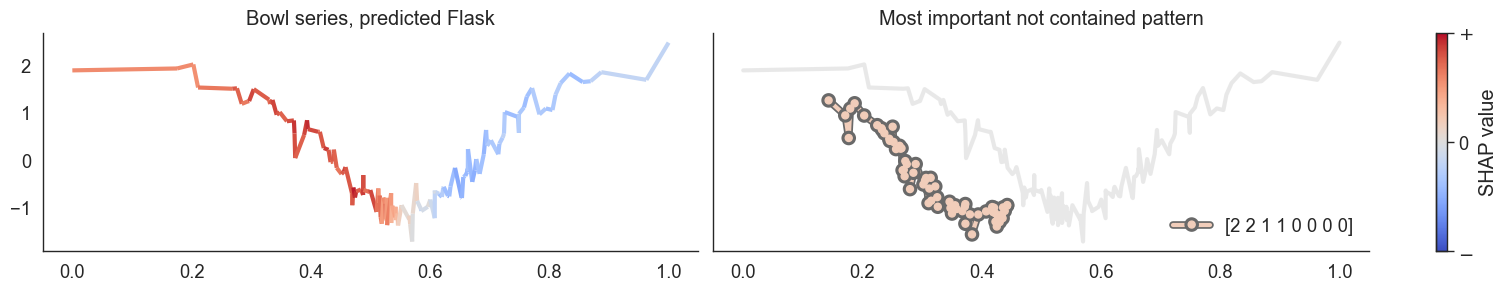

In [18]:
borf_irr, model_irr = pipe_irr[0], pipe_irr[-1]
Za_train, Za_test = pipe_irr[:-1].transform(Xa_train), pipe_irr[:-1].transform(Xa_test)
Fa = np.asarray(LinearExplainer(model_irr, Za_train).shap_values(Za_test)).transpose(2, 0, 1)
ya_pred = pipe_irr.predict(Xa_test)

mapper_irr = BagOfReceptiveFields(borf_irr)
mapper_irr.build(Xa_test, ya_test, ya_pred, task="classification")
mapper_irr.add_feature_importance(Fa)
mapper_irr.map_contained_feature_importance_to_saliency(count_overlapping=False)
mapper_irr.map_notcontained_feature_importance()

for c in range(3):
    plot_explanation(mapper_irr, np.flatnonzero(ya_pred == c)[0], abf_labels)

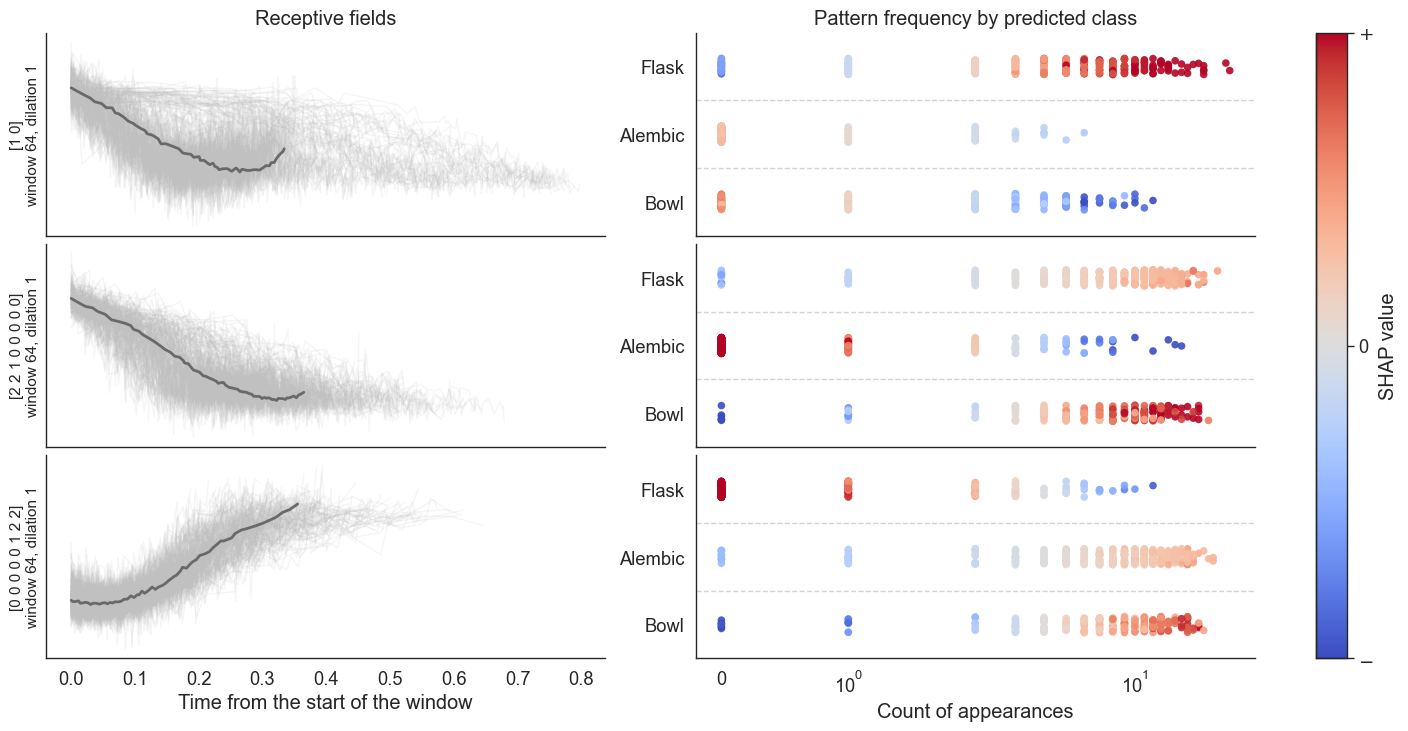

In [19]:
plot_top_patterns(mapper_irr, abf_labels, n_patterns=3);

In the receptive field below, look at how the segment means relate to their
points: observations far apart in time weigh more, so a segment mean can sit
away from where most of its points are, towards the sparsely sampled ones.

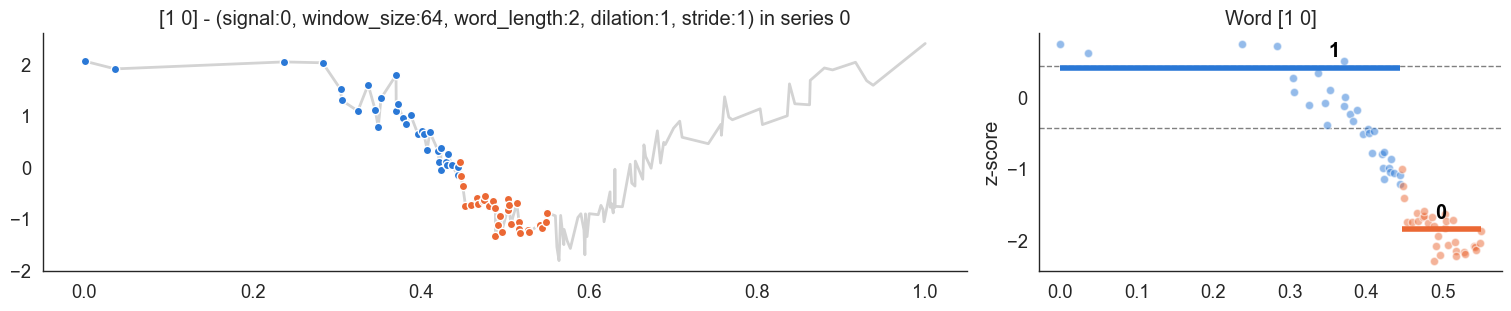

In [20]:
top = mapper_irr.F_avg_rank_argsort_[0]
i = next(i for i, a in enumerate(mapper_irr.receptive_fields_[top].alignments_indices) if len(a))
plot_receptive_field(mapper_irr, top, i);